# 청주·청원 통합과 재정자립도

- 실습 내용
    - 청주시와 비교도시의 재정자립도 변화 계산
        - 기간별 평균과 이중차분
        - 회귀계수와의 비교
        - 비교도시 변경과 사전 기간 위약 비교
- 실행 방법
    - Jupyter에서 위쪽 셀부터 차례로 실행
        - 패키지: `pandas`, `matplotlib`, `statsmodels`
        - 자료: `data/fiscal_autonomy.csv`

In [1]:
# 패키지가 없다면 다음 줄의 주석을 풀어 실행한다.
# %pip install -r requirements.txt

from pathlib import Path
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import statsmodels.formula.api as smf

DATA = Path("data/fiscal_autonomy.csv")
PRE_YEARS = [2009, 2010, 2011]
POST_YEARS = [2015, 2016, 2017, 2018, 2019]
CONTROL_POOL = ["전주시", "원주시", "포항시", "천안시"]
CITY_PROVINCES = {
    "청주시": "충청북도", "충북 청주시": "충청북도",
    "전주시": "전북특별자치도", "원주시": "강원특별자치도",
    "포항시": "경상북도", "천안시": "충청남도",
}

- 1. 자료 읽기
    - 출처: 행정안전부, 「지방자치단체 통합재정개요」
        - [KOSIS 재정자립도(시도/시/군/구)](https://kosis.kr/statHtml/statHtml.do?orgId=101&tblId=DT_1YL20921)
        - 수록 기간: 2001–2025년
        - 자료 이용: [KOSIS 통계정보 이용지침](https://stat.kosis.kr/nsistN/kosisUseGuide.do)
    - 지표: 일반회계 세입예산 중 지방세·세외수입의 비율
        - 당초예산 기준, 단위: %
        - 전 기간에 `세입과목개편전` 기준 적용
    - 파일 형식: CP949 인코딩, 두 줄의 열 이름
        - `sido`: 시도, `sgg`: 시군구
        - `year`: 연도, `fa`: 재정자립도

In [2]:
def load_kosis(path):
    """보관된 CP949·2단 헤더 CSV에서 개편 전 기준을 읽는다."""
    raw = pd.read_csv(path, encoding="cp949", header=[0, 1])
    raw.columns = [
        "sido" if i == 0 else "sgg" if i == 1 else f"{yr}_{kind}"
        for i, (yr, kind) in enumerate(raw.columns)
    ]
    cols = [c for c in raw.columns if "세입과목개편전" in c]
    if not cols:
        raise ValueError("세입과목 개편 전 기준의 열이 없습니다.")
    df = raw[["sido", "sgg"] + cols].melt(
        id_vars=["sido", "sgg"], var_name="col", value_name="fa")
    df["year"] = df["col"].str.extract(r"(\d{4})").astype(int)
    df["fa"] = pd.to_numeric(df["fa"], errors="coerce")
    return df.dropna(subset=["fa"])[["sido", "sgg", "year", "fa"]]

df_raw = load_kosis(DATA)
df_raw.head()

,sido,sgg,year,fa
0,전국,소계,2001,57.6
1,서울특별시,소계,2001,95.6
2,서울특별시,종로구,2001,72.3
3,서울특별시,중구,2001,95.0
4,서울특별시,용산구,2001,51.8


- 2. 비교할 도시 선택
    - 청주시와 네 비교도시 추출
        - 전주시·원주시·포항시·천안시
    - 자료의 지역명 정리
        - `충북 청주시`를 `청주시`로 연결
        - 원래 지역명은 `source_sgg`에 보관
        - 도시·연도별 중복값 확인

In [3]:
def unify_cheongju(df):
    """도시명을 정리하고 원래 표기를 source_sgg 열에 보관한다."""
    df = df.copy()
    df["sido"] = df["sido"].replace({
        "전라북도": "전북특별자치도", "강원도": "강원특별자치도"})
    keep = df["sgg"].isin(CITY_PROVINCES)
    keep &= df["sido"].eq(df["sgg"].map(CITY_PROVINCES))
    df = df.loc[keep].copy()
    df["source_sgg"] = df["sgg"]
    df["sgg"] = df["sgg"].replace({"충북 청주시": "청주시"})
    if df.duplicated(["sgg", "year"]).any():
        raise ValueError("도시·연도 중복값의 원자료를 확인해야 합니다.")
    return df.sort_values(["sgg", "year"]).reset_index(drop=True)

df = unify_cheongju(df_raw)
df[df["sgg"].eq("청주시") & df["year"].between(2011, 2016)]

,sido,sgg,year,fa,source_sgg
85,충청북도,청주시,2011,37.8,충북 청주시
86,충청북도,청주시,2012,38.3,충북 청주시
87,충청북도,청주시,2013,36.4,충북 청주시
88,충청북도,청주시,2014,36.0,충북 청주시
89,충청북도,청주시,2015,34.0,청주시
90,충청북도,청주시,2016,35.8,청주시


- 3. 재정자립도 추이 확인
    - 표시 기간: 2005–2022년
        - 청주시: 실선
        - 비교도시: 점선
    - 통합 시점과 분석 기간 표시
        - 수직선: 2014년 7월 통합
        - 음영: 본 비교에서 제외한 2012–2014년

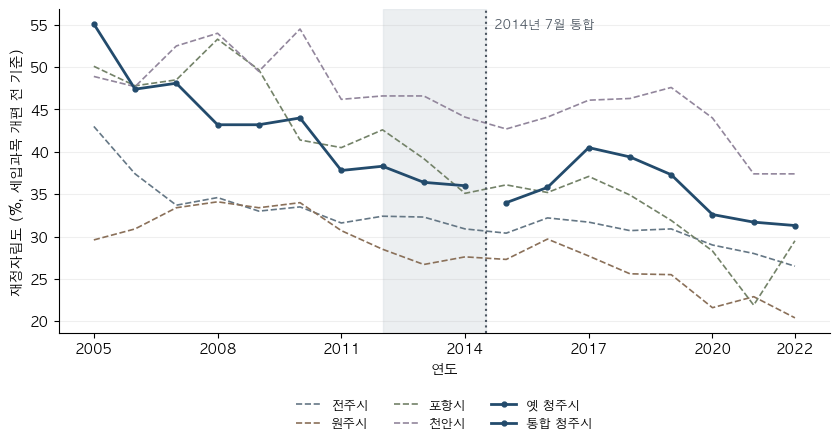

In [4]:
def plot_trends(df, treated, controls):
    available = {f.name for f in font_manager.fontManager.ttflist}
    for font in ["AppleGothic", "Malgun Gothic", "NanumGothic",
                 "Noto Sans CJK KR"]:
        if font in available:
            mpl.rcParams["font.family"] = font
            break
    mpl.rcParams["axes.unicode_minus"] = False
    keep = df[df["sgg"].isin([treated] + controls)
              & df["year"].between(2005, 2022)]
    fig, ax = plt.subplots(figsize=(8.5, 4.6))
    colors = ["#657785", "#8a7059", "#738268", "#92869c"]
    for city, color in zip(controls, colors):
        sub = keep[keep["sgg"] == city]
        ax.plot(sub["year"], sub["fa"], "--", color=color,
                linewidth=1.2, label=city)
    for original, label in [("충북 청주시", "옛 청주시"),
                             ("청주시", "통합 청주시")]:
        sub = keep[(keep["sgg"] == treated)
                   & (keep["source_sgg"] == original)]
        ax.plot(sub["year"], sub["fa"], "o-", color="#234b6c",
                markersize=3.5, linewidth=2, label=label)
    ax.axvline(2014.5, color="#4c5661", linestyle=":")
    ax.axvspan(2012, 2014.5, color="#dae0e5", alpha=0.5)
    ax.text(2014.7, ax.get_ylim()[1] - 1, "2014년 7월 통합",
            fontsize=9, va="top", color="#4c5661")
    ax.set_xlabel("연도")
    ax.set_xticks([2005, 2008, 2011, 2014, 2017, 2020, 2022])
    ax.set_ylabel("재정자립도 (%, 세입과목 개편 전 기준)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17),
              ncol=3, fontsize=9, frameon=False)
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    return fig


fig = plot_trends(df, "청주시", CONTROL_POOL)
plt.show()

- 4. 기간별 평균과 이중차분
    - 비교 대상: 청주시와 전주시
        - 사전 기간: 2009–2011년
        - 사후 기간: 2015–2019년
    - 계산 방법
        - 각 기간에 속하는 연도에 같은 가중치 부여
        - 도시별 사후 평균에서 사전 평균을 차감
        - 청주시의 변화에서 전주시의 변화를 차감
    - 단위
        - 재정자립도: %
        - 재정자립도의 차이: %p

In [5]:
def comparison_sample(df, treated, control, pre, post):
    """지정한 모든 도시·연도가 있는지 확인하고 비교 표본을 구성한다."""
    pre, post = list(pre), list(post)
    if not pre or not post or max(pre) >= min(post):
        raise ValueError("사전 기간은 사후 기간보다 앞서야 합니다.")
    if len(set(pre + post)) != len(pre + post) or treated == control:
        raise ValueError("연도와 비교집단의 중복을 확인하십시오.")
    cities, years = [treated, control], pre + post
    sub = df[df["sgg"].isin(cities) & df["year"].isin(years)].copy()
    expected = pd.MultiIndex.from_product([cities, years])
    actual = pd.MultiIndex.from_frame(sub[["sgg", "year"]])
    if actual.has_duplicates or len(expected.difference(actual)):
        raise ValueError("필요한 도시·연도 관측값이 없거나 중복됩니다.")
    if sub["fa"].isna().any():
        raise ValueError("결과변수에 결측값이 있습니다.")
    sub["post"] = sub["year"].isin(post).astype(int)
    sub["treat"] = sub["sgg"].eq(treated).astype(int)
    return sub

def did_2x2(df, treated, control, pre=PRE_YEARS, post=POST_YEARS):
    sub = comparison_sample(df, treated, control, pre, post)
    cells = sub.groupby(["treat", "post"])["fa"].mean().unstack()
    did = ((cells.loc[1, 1] - cells.loc[1, 0])
           - (cells.loc[0, 1] - cells.loc[0, 0]))
    return {
        "treated_pre": float(cells.loc[1, 0]),
        "treated_post": float(cells.loc[1, 1]),
        "control_pre": float(cells.loc[0, 0]),
        "control_post": float(cells.loc[0, 1]),
        "did": float(did), "n_obs": len(sub),
    }

In [6]:
base = did_2x2(df, "청주시", "전주시")
averages = pd.DataFrame({
    "사전 평균 (%)": [base["treated_pre"], base["control_pre"]],
    "사후 평균 (%)": [base["treated_post"], base["control_post"]],
}, index=pd.Index(["청주시", "전주시"], name="도시"))
averages["변화 (%p)"] = averages["사후 평균 (%)"] - averages["사전 평균 (%)"]
averages.round(2)

,사전 평균 (%),사후 평균 (%),변화 (%p)
도시,,,
청주시,41.67,37.40,-4.27
전주시,32.70,31.18,-1.52


In [7]:
treated_change = base["treated_post"] - base["treated_pre"]
control_change = base["control_post"] - base["control_pre"]
did_value = treated_change - control_change
print(f"청주시 변화: {treated_change:+.2f}%p")
print(f"전주시 변화: {control_change:+.2f}%p")
print(f"이중차분: {did_value:+.2f}%p")

청주시 변화: -4.27%p
전주시 변화: -1.52%p
이중차분: -2.75%p


- 5. 회귀계수와 비교
    - 모형: `fa ~ treat * post`
        - `treat`: 청주시이면 1, 전주시이면 0
        - `post`: 사후 기간이면 1, 사전 기간이면 0
        - `treat:post`: 두 변수의 상호작용
    - 상호작용항의 계수 확인
        - 네 칸의 평균으로 계산한 이중차분과 같은 값

In [8]:
sample = comparison_sample(df, "청주시", "전주시", PRE_YEARS, POST_YEARS)
model = smf.ols("fa ~ treat * post", data=sample).fit()
ols_did = float(model.params["treat:post"])
pd.DataFrame({
    "계산 방법": ["평균의 이중차분", "회귀 상호작용항"],
    "계산값 (%p)": [did_value, ols_did],
}).set_index("계산 방법").round(3)

,계산값 (%p)
계산 방법,
평균의 이중차분,-2.747
회귀 상호작용항,-2.747


- 6. 비교도시 변경
    - 청주시와 분석 기간은 동일하게 유지
        - 비교도시만 전주·원주·포항·천안으로 변경
    - 결과 비교
        - 비교도시의 변화가 다르면 이중차분도 달라짐
        - 부호와 크기를 함께 확인

In [9]:
comparisons = []
for city in CONTROL_POOL:
    result = did_2x2(df, "청주시", city)
    comparisons.append({
        "비교도시": city,
        "비교도시 사전 평균 (%)": result["control_pre"],
        "비교도시 사후 평균 (%)": result["control_post"],
        "이중차분 (%p)": result["did"],
    })
comparison_table = pd.DataFrame(comparisons).set_index("비교도시")
comparison_table.round(2)

,비교도시 사전 평균 (%),비교도시 사후 평균 (%),이중차분 (%p)
비교도시,,,
전주시,32.70,31.18,-2.75
원주시,32.70,27.16,1.27
포항시,43.87,35.04,4.56
천안시,50.07,45.36,0.44


- 7. 사전 기간 위약 비교
    - 통합 이전의 자료만 사용
        - 앞 기간: 2005–2008년
        - 뒤 기간: 2009–2011년
        - 가상의 정책 경계: 2009년
    - 점검할 내용
        - 통합 이전에도 두 도시의 변화가 달랐는지 확인
        - 사전 추세 그림과 함께 평행추세 검토에 활용

In [10]:
def placebo_pretrend(df, treated, control):
    return did_2x2(df, treated, control,
                   pre=[2005, 2006, 2007, 2008],
                   post=[2009, 2010, 2011])

placebos = []
for city in CONTROL_POOL:
    result = placebo_pretrend(df, "청주시", city)
    placebos.append({"비교도시": city, "위약 이중차분 (%p)": result["did"]})
placebo_table = pd.DataFrame(placebos).set_index("비교도시")
placebo_table.round(3)

,위약 이중차분 (%p)
비교도시,
전주시,-2.308
원주시,-7.483
포항시,-0.725
천안시,-6.075


- 주의사항
    - 청주시 자료의 통합 전후 지역 범위가 다름
        - 인과효과 분석에는 지역 범위의 조정과 식별가정 검토가 필요
    - 각 비교에 도시 두 곳만 사용
        - 표준오차와 유의확률은 제시하지 않음